<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/Regression_1_26_march.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1.** Explain the difference between simple linear regression and multiple linear regression. Provide an
example of each.

**Ans:**

### 🔹 1. Simple Linear Regression

* Uses **only one independent variable (X)** to predict a dependent variable (Y)
* Equation:
  [
  Y = b_0 + b_1X
  ]

👉 It shows the relationship between **one input and one output**

### 📌 Example:

Predicting **flight price based on duration**

* X = Duration
* Y = Price

👉 As duration increases, price may increase

---

### 🔹 2. Multiple Linear Regression

* Uses **two or more independent variables (X1, X2, X3...)**
* Equation:
  [
  Y = b_0 + b_1X_1 + b_2X_2 + b_3X_3 + \dots
  ]

👉 It shows the relationship between **multiple inputs and one output**

---

### 📌 Example:

Predicting **flight price based on multiple factors**

* X₁ = Duration
* X₂ = Total Stops
* X₃ = Airline
* X₄ = Journey Month
* Y = Price

👉 Price depends on many factors, not just one

---

## 🎯 Key Differences

| Feature       | Simple Linear Regression | Multiple Linear Regression          |
| ------------- | ------------------------ | ----------------------------------- |
| No. of inputs | 1                        | 2 or more                           |
| Complexity    | Simple                   | More complex                        |
| Accuracy      | Lower (limited data)     | Higher (more factors)               |
| Example       | Price vs Duration        | Price vs Duration + Stops + Airline |

---

## 🧾 Final Conclusion

* **Simple Linear Regression** is used when one variable affects the outcome
* **Multiple Linear Regression** is used when multiple factors influence the outcome (more realistic in real-world problems)



**Q2.** Discuss the assumptions of linear regression. How can you check whether these assumptions hold in
a given dataset?

**Ans:**✅ Assumptions of Linear Regression

Linear regression works properly only if certain assumptions are satisfied:

🔹 1. Linearity
Relationship between independent variables (X) and dependent variable (Y) should be linear

📌 Example: Price increases linearly with duration

🔹 2. Independence of Errors
Residuals (errors) should be independent
No relationship between consecutive errors
🔹 3. Homoscedasticity (Constant Variance)
Errors should have constant variance
Spread of residuals should be uniform
🔹 4. Normality of Residuals
Residuals should be normally distributed
🔹 5. No Multicollinearity (for multiple regression)
Independent variables should not be highly correlated with each other

In [2]:
from google.colab import files
data_to_load = files.upload()

Saving flight_price.xlsx to flight_price.xlsx


In [3]:
import pandas as pd
df = pd.read_excel("flight_price.xlsx")

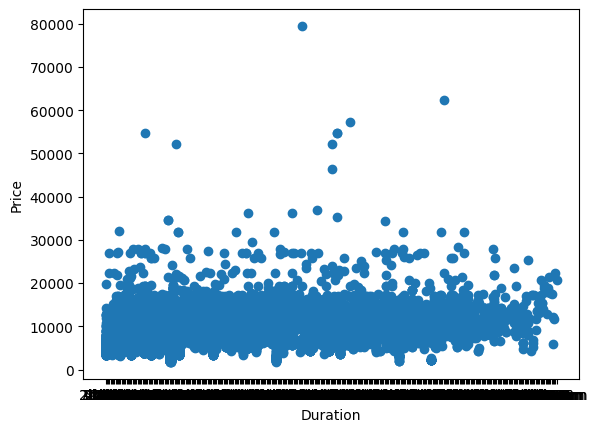

In [4]:
#How to Check These Assumptions
#1. Check Linearity
import matplotlib.pyplot as plt

plt.scatter(df["Duration"], df["Price"])
plt.xlabel("Duration")
plt.ylabel("Price")
plt.show()

In [8]:
import pandas as pd

# Example conversion function
def convert_duration(x):
    hours = 0
    minutes = 0

    if 'h' in x:
        hours = int(x.split('h')[0])
    if 'm' in x:
        minutes = int(x.split('m')[0].split()[-1])

    return hours * 60 + minutes  # convert to minutes

In [9]:
df["Duration"] = df["Duration"].apply(convert_duration)

In [10]:
#2. Check Independence
#Use Durbin-Watson test
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Example features (adjust based on your dataset)
X = df[["Duration"]]   # or multiple features
y = df["Price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Residuals (THIS WAS MISSING)
residuals = y_test - y_pred

# Durbin-Watson test
dw = durbin_watson(residuals)

print("Durbin-Watson value:", dw)

Durbin-Watson value: 1.9343132679204864


In [11]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson(residuals)

np.float64(1.9343132679204864)

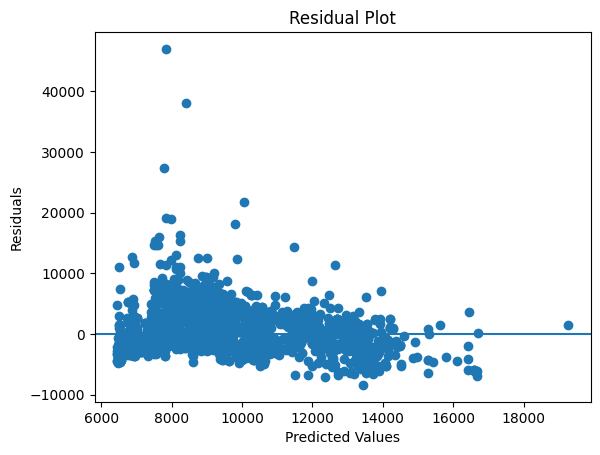

In [13]:
#3. Check Homoscedasticity
# Predictions  ✅
predictions = model.predict(X_test)

# Residuals  ✅
residuals = y_test - predictions

# Homoscedasticity plot
plt.scatter(predictions, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

<Axes: xlabel='Price', ylabel='Count'>

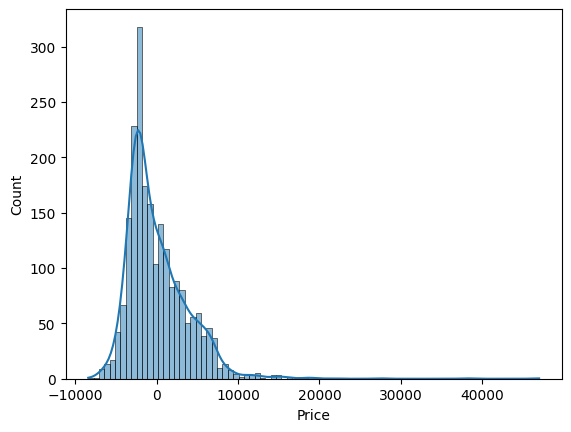

In [14]:
#4. Check Normality
import seaborn as sns #Should look like bell curve

sns.histplot(residuals, kde=True)

In [15]:
#5. Check Multicollinearity
import seaborn as sns

sns.heatmap(df.corr(), annot=True)

ValueError: could not convert string to float: 'IndiGo'

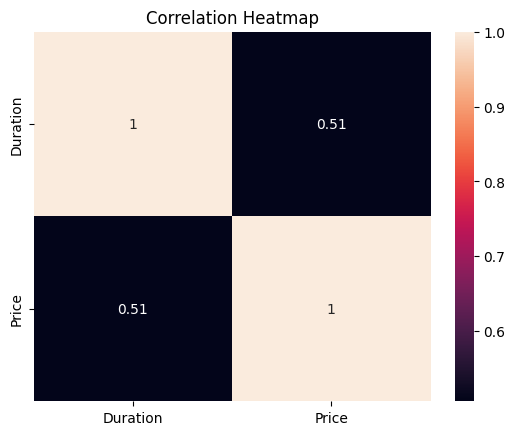

In [16]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Q3.** How do you interpret the slope and intercept in a linear regression model? Provide an example using
a real-world scenario.

**Ans:**


## ✅ Interpretation of Slope and Intercept in Linear Regression

A linear regression model is written as:

[
Y = b_0 + b_1X
]

Where:

* **(b_0)** = Intercept
* **(b_1)** = Slope

---

### 🔹 1. Slope ((b_1))

* The slope represents the **change in the dependent variable (Y)** for a **one-unit change in the independent variable (X)**
* It shows the **strength and direction** of the relationship

👉 If slope is:

* Positive → Y increases as X increases
* Negative → Y decreases as X increases

---

### 🔹 2. Intercept ((b_0))

* The intercept is the **value of Y when X = 0**
* It represents the **baseline value**

---

## 📌 Real-World Example (Flight Price)

Suppose the regression model is:

[
\text{Price} = 2000 + 50 \times \text{Duration}
]

---

### 🔍 Interpretation

* **Intercept = 2000**
  👉 Base ticket price is ₹2000 when duration = 0
  *(theoretical starting price)*

* **Slope = 50**
  👉 For every 1 unit increase in duration (e.g., 1 minute/hour),
  price increases by ₹50

---

### 🎯 Meaning

* Longer flights → higher prices
* ₹50 increase per unit duration

---



> In a linear regression model, the slope represents the rate of change of the dependent variable with respect to the independent variable, while the intercept represents the value of the dependent variable when the independent variable is zero. For example, in predicting flight price based on duration, the slope indicates how much the price increases for each additional unit of travel time, and the intercept represents the base price when the duration is zero.



> The intercept may not always have practical meaning if X = 0 is not realistic in the real-world scenario.




**Q4.** Explain the concept of gradient descent. How is it used in machine learning?

**Ans:**

## ✅ Concept of Gradient Descent

**Gradient Descent** is an optimization algorithm used to **minimize the error (loss function)** in machine learning models.

👉 It works by **iteratively adjusting model parameters (like slope and intercept)** to find the best fit line.

---

## 🧠 Intuition (Simple Idea)

Imagine you are standing on a hill and want to reach the **lowest point (minimum error)**:

* You take small steps downhill
* At each step, you check the slope
* Move in the direction where the slope decreases

👉 This process continues until you reach the **minimum point**

---

## 📉 Mathematical Idea

Model tries to minimize:

[
\text{Loss Function} = \text{Error between actual and predicted values}
]

Gradient Descent updates parameters like:

[
\theta = \theta - \alpha \times \text{gradient}
]

Where:

* **(\theta)** = model parameters (slope, intercept)
* **(\alpha)** = learning rate (step size)
* **gradient** = direction of maximum increase

👉 We subtract to move toward **minimum**

---

## 🔄 Steps in Gradient Descent

1. Initialize parameters randomly
2. Calculate predictions
3. Compute error (loss)
4. Calculate gradient
5. Update parameters
6. Repeat until error is minimized

---

## 🤖 Use in Machine Learning

Gradient Descent is used to:

* Train **linear regression models**
* Train **logistic regression models**
* Train **neural networks (deep learning)**

👉 It helps models **learn from data by reducing error**

---

## 📌 Example (Flight Price)

* Model predicts flight price
* Initially predictions are wrong
* Gradient Descent adjusts:

  * slope
  * intercept
    👉 until predicted prices are close to actual prices



> Gradient Descent is an optimization algorithm used to minimize the loss function by iteratively updating model parameters in the direction of the negative gradient. It is widely used in machine learning models such as linear regression and neural networks to find the optimal values of parameters that reduce prediction error.



> Choosing an appropriate learning rate is important, as a very large value may cause overshooting, while a very small value may slow down convergence.




In [17]:
#Gradient Descent from Scratch
import numpy as np
import matplotlib.pyplot as plt

# Sample data (Duration vs Price)
X = np.array([1, 2, 3, 4, 5])   # e.g., hours
y = np.array([200, 400, 600, 800, 1000])  # price

# Initialize parameters
m = 0   # slope
b = 0   # intercept
learning_rate = 0.01
epochs = 1000

n = len(X)

# Gradient Descent
for i in range(epochs):
    y_pred = m * X + b

    # Calculate gradients
    dm = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    # Update parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db

# Final parameters
print("Slope (m):", m)
print("Intercept (b):", b)

Slope (m): 199.5180350671978
Intercept (b): 1.74004633406103


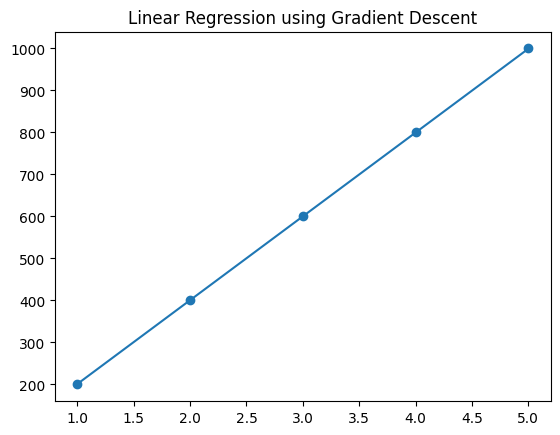

In [18]:
#Plot Result
plt.scatter(X, y)
plt.plot(X, m*X + b)
plt.title("Linear Regression using Gradient Descent")
plt.show()

In [19]:
#2. Using sklearn (internally uses optimization)
from sklearn.linear_model import LinearRegression

X = X.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 200.0
Intercept: 0.0


##When to use

Gradient Descent is used in:

Linear Regression
Logistic Regression
Neural Networks

**Q5.** Describe the multiple linear regression model. How does it differ from simple linear regression?

**Ans:**


## ✅ Multiple Linear Regression Model

**Multiple Linear Regression** is used to model the relationship between **one dependent variable (Y)** and **two or more independent variables (X₁, X₂, X₃, …)**.

### 📌 Equation:

[
Y = b_0 + b_1X_1 + b_2X_2 + b_3X_3 + \dots + b_nX_n
]

Where:

* **(Y)** = dependent variable (target)
* **(X_1, X_2, X_3)** = independent variables (features)
* **(b_0)** = intercept
* **(b_1, b_2, b_3)** = coefficients

---

## 📊 Example (Real-world)

Predicting **flight price** using multiple factors:

* (X_1) = Duration
* (X_2) = Total Stops
* (X_3) = Airline
* (X_4) = Journey Month

👉 Price depends on all these variables together

---

## 🔍 How it works

* Each independent variable contributes to the prediction
* Model finds the **best combination of coefficients**
* Captures more realistic relationships compared to single-variable models

---

## 🔄 Difference from Simple Linear Regression

| Feature       | Simple Linear Regression | Multiple Linear Regression          |
| ------------- | ------------------------ | ----------------------------------- |
| No. of inputs | 1                        | 2 or more                           |
| Equation      | (Y = b_0 + b_1X)         | (Y = b_0 + b_1X_1 + b_2X_2 + ...)   |
| Complexity    | Simple                   | More complex                        |
| Accuracy      | Lower                    | Higher (more realistic)             |
| Example       | Price vs Duration        | Price vs Duration + Stops + Airline |

---

## 🎯 Key Points

* Multiple regression considers **multiple factors simultaneously**
* Provides **better prediction accuracy**
* More suitable for real-world problems

---


> Multiple Linear Regression is a statistical technique used to model the relationship between one dependent variable and two or more independent variables. It extends simple linear regression by incorporating multiple predictors, allowing for more accurate and realistic predictions. Unlike simple linear regression, which uses only one independent variable, multiple linear regression considers several factors simultaneously to explain the variation in the dependent variable.

---


Add:

> However, multiple linear regression requires careful handling of multicollinearity and assumptions to ensure model reliability.




In [20]:
#1. Basic Multiple Linear Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_excel("flight_price.xlsx")

# ---- Convert Duration (text → numeric) ----
def convert_duration(x):
    hours = 0
    minutes = 0

    if 'h' in x:
        hours = int(x.split('h')[0])
    if 'm' in x:
        minutes = int(x.split('m')[0].split()[-1])

    return hours * 60 + minutes

df["Duration"] = df["Duration"].apply(convert_duration)

# ---- Encode categorical columns ----
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# ---- Define features (X) and target (y) ----
X = df.drop("Price", axis=1)
y = df["Price"]

# ---- Train-test split ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ---- Train model ----
model = LinearRegression()
model.fit(X_train, y_train)

# ---- Predictions ----
y_pred = model.predict(X_test)

# ---- Coefficients ----
print("Intercept:", model.intercept_)
print("Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(col, ":", coef)

Intercept: 8013.830123764627
Coefficients:
Airline : 45.45062799395278
Date_of_Journey : -6.522756831117622
Source : -215.97045101820405
Destination : 362.6230543147475
Route : -7.667492558366758
Dep_Time : 2.6097883186332487
Arrival_Time : -0.425116434907224
Duration : 2.5229360384625537
Total_Stops : -1286.5714647601746
Additional_Info : 256.5227548630105


In [21]:
#2. Model Evaluation (important)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2545.0167773108706
MSE: 11776564.179156298
R2 Score: 0.3936723919775351


**Q6.** Explain the concept of multicollinearity in multiple linear regression. How can you detect and
address this issue?

**Ans:** ✅ Concept of Multicollinearity

Multicollinearity occurs in multiple linear regression when two or more independent variables are highly correlated with each other.

👉 This means they provide similar information, making it difficult for the model to distinguish their individual effects on the dependent variable.

⚠️ Why it is a Problem
Coefficients become unstable and unreliable
Hard to interpret which variable is actually important
Small data changes can cause large changes in results
Model may lose accuracy and generalization
📌 Example (Real-world)

In a flight dataset:

Duration and Total Stops may be highly correlated
👉 More stops → longer duration

➡️ This creates multicollinearity

🔍 How to Detect Multicollinearity

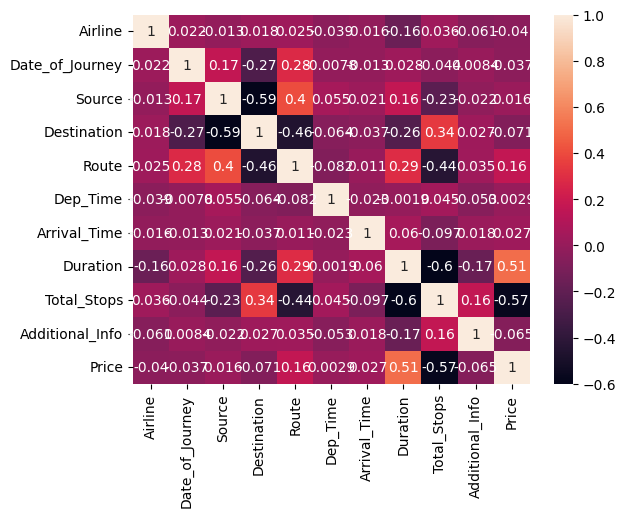

In [22]:
#1. Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [23]:
#2. Variance Inflation Factor (VIF) (Best method)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.select_dtypes(include=['int64','float64'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

            Feature        VIF
0           Airline   3.729926
1   Date_of_Journey   5.101622
2            Source   5.578851
3       Destination   3.164618
4             Route   7.946980
5          Dep_Time   3.975153
6      Arrival_Time   7.287445
7          Duration   4.298477
8       Total_Stops   3.460372
9   Additional_Info  23.402919
10            Price   7.659846


🛠️ How to Fix Multicollinearity

✅ 1. Remove Highly Correlated Features
Drop one of the correlated variables

✅ 2. Feature Selection
Keep only important variables

✅ 3. Use Regularization Techniques
Ridge Regression (L2)
Lasso Regression (L1)

✅ 4. Combine Features
Create new feature (e.g., combine related variables)

Multicollinearity occurs when independent variables in a multiple linear regression model are highly correlated with each other. This can lead to unstable coefficients and difficulty in interpreting the model. It can be detected using correlation matrices and Variance Inflation Factor (VIF). To address multicollinearity, one can remove highly correlated variables, apply feature selection techniques, or use regularization methods such as Ridge or Lasso regression.

**Q7.** Describe the polynomial regression model. How is it different from linear regression?

**Ans:**
## ✅ Polynomial Regression Model

**Polynomial Regression** is an extension of linear regression that models the relationship between the independent variable (X) and dependent variable (Y) as an **nth-degree polynomial**.

### 📌 Equation (example for degree 2):

[
Y = b_0 + b_1X + b_2X^2
]

👉 Even though it includes (X^2, X^3,) etc., it is still a **linear model in terms of coefficients (b₀, b₁, b₂)**.

---

## 🧠 Concept

* Used when the relationship between variables is **non-linear**
* Fits a **curved line** instead of a straight line

---

## 📊 Example (Real-world)

In a flight dataset:

* Price may not increase linearly with duration
* After a certain point, price may increase faster

👉 Polynomial regression captures this **curved relationship**

---

## 🔄 Difference from Linear Regression

| Feature      | Linear Regression | Polynomial Regression           |
| ------------ | ----------------- | ------------------------------- |
| Relationship | Straight line     | Curved line                     |
| Equation     | (Y = b_0 + b_1X)  | (Y = b_0 + b_1X + b_2X^2 + ...) |
| Complexity   | Simple            | More complex                    |
| Use case     | Linear data       | Non-linear data                 |
| Flexibility  | Low               | High                            |

---

## 🎯 Key Points

* Captures **non-linear patterns**
* More flexible than linear regression
* Risk of **overfitting** if degree is too high

---



> Polynomial Regression is a type of regression analysis in which the relationship between the independent and dependent variables is modeled as a polynomial equation. Unlike linear regression, which fits a straight line, polynomial regression fits a curved line to capture non-linear relationships. It is useful when data shows a non-linear trend, but it may lead to overfitting if the degree of the polynomial is too high.

---

> Choosing the correct polynomial degree is important to balance model accuracy and avoid overfitting.



In [24]:
#1. Polynomial Regression (Python Code)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Sample data (non-linear)
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([100, 300, 600, 1000, 1500])

# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X, y)

# Polynomial Regression (degree = 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

LinearRegression()

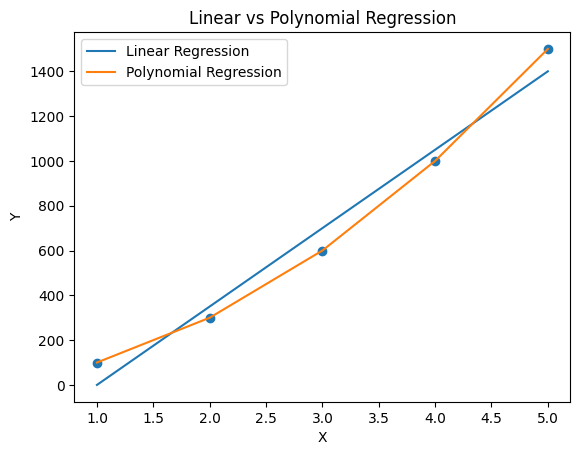

In [25]:
#2. Plot: Linear vs Polynomial
# Plot data points
plt.scatter(X, y)

# Linear line
plt.plot(X, lin_model.predict(X), label="Linear Regression")

# Polynomial curve
plt.plot(X, poly_model.predict(X_poly), label="Polynomial Regression")

plt.title("Linear vs Polynomial Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

**Q8.** What are the advantages and disadvantages of polynomial regression compared to linear
regression? In what situations would you prefer to use polynomial regression?

**Ans:**

## ✅ Advantages and Disadvantages of Polynomial Regression

### 🔹 Advantages

1. **Captures Non-linear Relationships**

   * Models curved patterns that linear regression cannot handle

2. **Better Fit for Complex Data**

   * Provides more accurate predictions when data is not linear

3. **Flexible Model**

   * Degree can be increased to fit different patterns

---

### 🔹 Disadvantages

1. **Overfitting Risk**

   * High-degree polynomials may fit noise instead of actual pattern

2. **Complexity Increases**

   * Harder to interpret compared to linear regression

3. **Sensitive to Outliers**

   * Extreme values can distort the curve significantly

4. **Poor Extrapolation**

   * Predictions outside the data range can be unrealistic

---

## 🔄 Comparison with Linear Regression

| Feature             | Linear Regression | Polynomial Regression       |
| ------------------- | ----------------- | --------------------------- |
| Relationship        | Straight line     | Curved line                 |
| Flexibility         | Low               | High                        |
| Risk of Overfitting | Low               | High                        |
| Interpretability    | Easy              | Difficult                   |
| Use Case            | Simple patterns   | Complex/non-linear patterns |

---

## 🎯 When to Use Polynomial Regression

You should prefer polynomial regression when:

* Data shows a **curved or non-linear trend**
* Linear regression gives **poor fit (underfitting)**
* Relationship between variables is **not straight-line**

---

## 📌 Example

In flight price analysis:

* Price may increase slowly at first and then rapidly
  👉 This non-linear trend can be modeled better using polynomial regression

---

> Polynomial regression has the advantage of capturing non-linear relationships and providing a better fit for complex data compared to linear regression. However, it has disadvantages such as increased risk of overfitting, higher complexity, and sensitivity to outliers. Polynomial regression is preferred when the data exhibits a non-linear trend and linear regression fails to capture the underlying pattern effectively.



> Proper selection of polynomial degree is important to balance bias and variance.


